In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/punicbyte/500-very-long/synthetic_memory_500_very_long(1).csv
/kaggle/input/datasets/punicbyte/synthetic-sequences/synthetic_memory_100 (1).csv
/kaggle/input/datasets/punicbyte/synthetic-memory-bigger/synthetic_memory_500_harder.csv


# CSV loading + DataLoader + FixedWindowMLP + VanillaRNN

In [2]:
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
csv_files = glob.glob(
    "/kaggle/input/datasets/punicbyte/500-very-long/synthetic_memory_500_very_long(1).csv",
    recursive=True
)

if not csv_files:
    raise FileNotFoundError("Could not find synthetic_memory_100*.csv")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print("CSV path:", csv_path)
print(df.head())
print("\nSplit counts:")
print(df["split"].value_counts())

CSV path: /kaggle/input/datasets/punicbyte/500-very-long/synthetic_memory_500_very_long(1).csv
   id  split difficulty  sequence_length  target_position  distance_to_query  \
0   0  train      short              207               52                154   
1   1  train       long              492               82                409   
2   2  train       long              493               57                435   
3   3  train     medium              374               23                350   
4   4  train       long              481               69                411   

                                            sequence target_token  label  \
0  START silver paper desk library music pencil k...          RED      0   
1  START lamp library camera pizza tree cloud but...         BLUE      1   
2  START paper pizza forest pencil clock library ...          RED      0   
3  START car forest mirror flower window orange l...         BLUE      1   
4  START notebook phone shirt car ocean mach

In [4]:
df["tokens"] = df["sequence"].astype(str).str.split()

all_tokens = sorted({
    token
    for tokens in df["tokens"]
    for token in tokens
})

id_to_token = ["<PAD>"] + all_tokens
token_to_id = {token: idx for idx, token in enumerate(id_to_token)}
vocab_size = len(id_to_token)
pad_id = token_to_id["<PAD>"]

df["token_ids"] = df["tokens"].apply(
    lambda tokens: [token_to_id[token] for token in tokens]
)

max_length = df["token_ids"].str.len().max()

# Left padding keeps the final QUERY token at the last position.
def left_pad(token_ids):
    return [pad_id] * (max_length - len(token_ids)) + token_ids

train_df = df[df["split"].eq("train")].copy()
val_df = df[df["split"].eq("val")].copy()

X_train = torch.tensor(
    train_df["token_ids"].apply(left_pad).tolist(),
    dtype=torch.long
)
y_train = torch.tensor(train_df["label"].to_numpy(), dtype=torch.long)

X_val = torch.tensor(
    val_df["token_ids"].apply(left_pad).tolist(),
    dtype=torch.long
)
y_val = torch.tensor(val_df["label"].to_numpy(), dtype=torch.long)

print("Vocabulary size:", vocab_size)
print("Train count:", len(X_train))
print("Validation count:", len(X_val))

Vocabulary size: 49
Train count: 400
Validation count: 100


In [5]:
batch_size = 16

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

loader_generator = torch.Generator().manual_seed(seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

batch_X, batch_y = next(iter(train_loader))
print("Batch X shape:", batch_X.shape)
print("Batch y shape:", batch_y.shape)

Batch X shape: torch.Size([16, 598])
Batch y shape: torch.Size([16])


In [6]:
class FixedWindowMLP(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=32,
        window_size=5,
        hidden_size=64,
        num_classes=2,
        padding_idx=0
    ):
        super().__init__()
        self.window_size = window_size
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )
        self.mlp = nn.Sequential(
            nn.Linear(window_size * embedding_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # QUERY is final; select the preceding fixed window.
        window = x[:, -(self.window_size + 1):-1]
        embedded = self.embedding(window)
        flattened = embedded.reshape(embedded.size(0), -1)
        return self.mlp(flattened)

In [7]:
class VanillaRNNFromScratch(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=32,
        hidden_size=64,
        num_classes=2,
        padding_idx=0
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.padding_idx = padding_idx

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )
        self.input_to_hidden = nn.Linear(
            embedding_dim,
            hidden_size
        )
        self.hidden_to_hidden = nn.Linear(
            hidden_size,
            hidden_size,
            bias=False
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        batch_size, sequence_length, _ = embedded.shape

        hidden_state = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        for timestep in range(sequence_length):
            candidate_state = torch.tanh(
                self.input_to_hidden(embedded[:, timestep, :])
                + self.hidden_to_hidden(hidden_state)
            )

            is_not_padding = (
                x[:, timestep] != self.padding_idx
            ).unsqueeze(1)

            hidden_state = torch.where(
                is_not_padding,
                candidate_state,
                hidden_state
            )

        return self.classifier(hidden_state)

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_examples += labels.size(0)

    return total_loss / total_examples


def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return correct / total


def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    lr,
    device
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_accuracy": []
    }

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )
        val_accuracy = evaluate_accuracy(
            model,
            val_loader,
            device
        )

        history["train_loss"].append(train_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val accuracy: {val_accuracy:.4f}"
        )

    return history

In [9]:
fixed_window_model = FixedWindowMLP(
    vocab_size=vocab_size,
    embedding_dim=32,
    window_size=5,
    hidden_size=64,
    num_classes=2,
    padding_idx=pad_id
)

fixed_window_history = train_model(
    fixed_window_model,
    train_loader,
    val_loader,
    epochs=25,
    lr=0.001,
    device=device
)

fixed_window_val_acc = evaluate_accuracy(
    fixed_window_model,
    val_loader,
    device
)

Epoch 01 | Train loss: 0.5499 | Val accuracy: 0.9100
Epoch 02 | Train loss: 0.2892 | Val accuracy: 0.9200
Epoch 03 | Train loss: 0.1651 | Val accuracy: 0.9200
Epoch 04 | Train loss: 0.1094 | Val accuracy: 0.9200
Epoch 05 | Train loss: 0.0746 | Val accuracy: 0.9200
Epoch 06 | Train loss: 0.0531 | Val accuracy: 0.9300
Epoch 07 | Train loss: 0.0388 | Val accuracy: 0.9300
Epoch 08 | Train loss: 0.0290 | Val accuracy: 0.9300
Epoch 09 | Train loss: 0.0219 | Val accuracy: 0.9200
Epoch 10 | Train loss: 0.0168 | Val accuracy: 0.9200
Epoch 11 | Train loss: 0.0136 | Val accuracy: 0.9100
Epoch 12 | Train loss: 0.0110 | Val accuracy: 0.9100
Epoch 13 | Train loss: 0.0090 | Val accuracy: 0.9100
Epoch 14 | Train loss: 0.0076 | Val accuracy: 0.9100
Epoch 15 | Train loss: 0.0065 | Val accuracy: 0.9100
Epoch 16 | Train loss: 0.0055 | Val accuracy: 0.9100
Epoch 17 | Train loss: 0.0048 | Val accuracy: 0.9100
Epoch 18 | Train loss: 0.0043 | Val accuracy: 0.9100
Epoch 19 | Train loss: 0.0037 | Val accuracy: 

In [10]:
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

vanilla_rnn_model = VanillaRNNFromScratch(
    vocab_size=vocab_size,
    embedding_dim=32,
    hidden_size=64,
    num_classes=2,
    padding_idx=pad_id
)

vanilla_rnn_history = train_model(
    vanilla_rnn_model,
    train_loader,
    val_loader,
    epochs=25,
    lr=0.001,
    device=device
)

vanilla_rnn_val_acc = evaluate_accuracy(
    vanilla_rnn_model,
    val_loader,
    device
)

Epoch 01 | Train loss: 0.6360 | Val accuracy: 0.8900
Epoch 02 | Train loss: 0.2789 | Val accuracy: 0.9900
Epoch 03 | Train loss: 0.0425 | Val accuracy: 1.0000
Epoch 04 | Train loss: 0.0108 | Val accuracy: 1.0000
Epoch 05 | Train loss: 0.0168 | Val accuracy: 1.0000
Epoch 06 | Train loss: 0.0041 | Val accuracy: 1.0000
Epoch 07 | Train loss: 0.0029 | Val accuracy: 1.0000
Epoch 08 | Train loss: 0.0133 | Val accuracy: 1.0000
Epoch 09 | Train loss: 0.0029 | Val accuracy: 1.0000
Epoch 10 | Train loss: 0.0020 | Val accuracy: 1.0000
Epoch 11 | Train loss: 0.0015 | Val accuracy: 1.0000
Epoch 12 | Train loss: 0.0108 | Val accuracy: 0.9900
Epoch 13 | Train loss: 0.0023 | Val accuracy: 1.0000
Epoch 14 | Train loss: 0.0011 | Val accuracy: 1.0000
Epoch 15 | Train loss: 0.0008 | Val accuracy: 1.0000
Epoch 16 | Train loss: 0.0007 | Val accuracy: 1.0000
Epoch 17 | Train loss: 0.0006 | Val accuracy: 1.0000
Epoch 18 | Train loss: 0.0066 | Val accuracy: 1.0000
Epoch 19 | Train loss: 0.0191 | Val accuracy: 

In [11]:
print(
    f"FixedWindowMLP final val accuracy: "
    f"{fixed_window_val_acc:.4f}"
)
print(
    f"VanillaRNN final val accuracy: "
    f"{vanilla_rnn_val_acc:.4f}"
)

FixedWindowMLP final val accuracy: 0.9100
VanillaRNN final val accuracy: 1.0000


# LSTM from scratch + comparison

In [12]:
class LSTMFromScratch(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=32,
        hidden_size=64,
        num_classes=2,
        padding_idx=0
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.padding_idx = padding_idx

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )

        combined_size = embedding_dim + hidden_size

        self.forget_layer = nn.Linear(combined_size, hidden_size)
        self.input_layer = nn.Linear(combined_size, hidden_size)
        self.candidate_layer = nn.Linear(combined_size, hidden_size)
        self.output_layer = nn.Linear(combined_size, hidden_size)

        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x, return_gates=False):
        embedded = self.embedding(x)
        batch_size, seq_len, _ = embedded.shape

        hidden_state = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        cell_state = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        forget_gate_values = []
        input_gate_values = []
        output_gate_values = []

        for timestep in range(seq_len):
            x_t = embedded[:, timestep, :]

            concat = torch.cat([x_t, hidden_state], dim=1)

            forget_gate = torch.sigmoid(self.forget_layer(concat))
            input_gate = torch.sigmoid(self.input_layer(concat))
            candidate_cell = torch.tanh(self.candidate_layer(concat))
            output_gate = torch.sigmoid(self.output_layer(concat))

            updated_cell_state = (
                forget_gate * cell_state
                + input_gate * candidate_cell
            )

            updated_hidden_state = output_gate * torch.tanh(updated_cell_state)

            is_not_padding = (x[:, timestep] != self.padding_idx).unsqueeze(1)

            cell_state = torch.where(
                is_not_padding,
                updated_cell_state,
                cell_state
            )

            hidden_state = torch.where(
                is_not_padding,
                updated_hidden_state,
                hidden_state
            )

            if return_gates:
                forget_gate_values.append(forget_gate)
                input_gate_values.append(input_gate)
                output_gate_values.append(output_gate)

        logits = self.classifier(hidden_state)

        if not return_gates:
            return logits

        gates = {
            "forget_gates": torch.stack(forget_gate_values, dim=1),
            "input_gates": torch.stack(input_gate_values, dim=1),
            "output_gates": torch.stack(output_gate_values, dim=1),
        }

        return logits, gates

In [13]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

lstm_model = LSTMFromScratch(
    vocab_size,
    embedding_dim=32,
    hidden_size=64,
    num_classes=2,
    padding_idx=pad_id
).to(device)

lstm_history = train_model(
    lstm_model,
    train_loader,
    val_loader,
    epochs=25,
    lr=0.001,
    device=device
)

lstm_val_acc = evaluate_accuracy(
    lstm_model,
    val_loader,
    device
)

Epoch 01 | Train loss: 0.6192 | Val accuracy: 0.9700
Epoch 02 | Train loss: 0.1330 | Val accuracy: 1.0000
Epoch 03 | Train loss: 0.0145 | Val accuracy: 1.0000
Epoch 04 | Train loss: 0.0098 | Val accuracy: 1.0000
Epoch 05 | Train loss: 0.0057 | Val accuracy: 1.0000
Epoch 06 | Train loss: 0.0036 | Val accuracy: 1.0000
Epoch 07 | Train loss: 0.0025 | Val accuracy: 1.0000
Epoch 08 | Train loss: 0.0019 | Val accuracy: 1.0000
Epoch 09 | Train loss: 0.0015 | Val accuracy: 1.0000
Epoch 10 | Train loss: 0.0012 | Val accuracy: 1.0000
Epoch 11 | Train loss: 0.0010 | Val accuracy: 1.0000
Epoch 12 | Train loss: 0.0009 | Val accuracy: 1.0000
Epoch 13 | Train loss: 0.0008 | Val accuracy: 1.0000
Epoch 14 | Train loss: 0.0007 | Val accuracy: 1.0000
Epoch 15 | Train loss: 0.0006 | Val accuracy: 1.0000
Epoch 16 | Train loss: 0.0005 | Val accuracy: 1.0000
Epoch 17 | Train loss: 0.0005 | Val accuracy: 1.0000
Epoch 18 | Train loss: 0.0004 | Val accuracy: 1.0000
Epoch 19 | Train loss: 0.0004 | Val accuracy: 

In [14]:
sample_inputs, _ = next(iter(val_loader))

with torch.no_grad():
    sample_logits, sample_gates = lstm_model(
        sample_inputs.to(device),
        return_gates=True
    )

print("Logits shape:", sample_logits.shape)
print(
    "Forget gates shape:",
    sample_gates["forget_gates"].shape
)
print(
    "Input gates shape:",
    sample_gates["input_gates"].shape
)
print(
    "Output gates shape:",
    sample_gates["output_gates"].shape
)

Logits shape: torch.Size([16, 2])
Forget gates shape: torch.Size([16, 598, 64])
Input gates shape: torch.Size([16, 598, 64])
Output gates shape: torch.Size([16, 598, 64])


In [15]:
comparison_df = pd.DataFrame({
    "model": [
        "FixedWindowMLP",
        "VanillaRNNFromScratch",
        "LSTMFromScratch"
    ],
    "validation_accuracy": [
        fixed_window_val_acc,
        vanilla_rnn_val_acc,
        lstm_val_acc
    ]
})

print(comparison_df.to_string(index=False))

                model  validation_accuracy
       FixedWindowMLP                 0.91
VanillaRNNFromScratch                 1.00
      LSTMFromScratch                 1.00


In [16]:
def evaluate_by_difficulty(model, df, token_to_id, device):
    model.eval()
    results = []

    for difficulty in ["short", "medium", "long"]:
        subset = df[(df["split"] == "val") & (df["difficulty"] == difficulty)]

        correct = 0
        total = 0

        for _, row in subset.iterrows():
            token_ids = [token_to_id[token] for token in row["sequence"].split()]
            token_ids = [pad_id] * (max_length - len(token_ids)) + token_ids

            x = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)
            y_true = int(row["label"])

            with torch.no_grad():
                logits = model(x)
                pred = logits.argmax(dim=1).item()

            correct += int(pred == y_true)
            total += 1

        accuracy = correct / total if total > 0 else 0.0

        results.append({
            "difficulty": difficulty,
            "correct": correct,
            "total": total,
            "accuracy": accuracy
        })

    return pd.DataFrame(results)

In [17]:
print("FixedWindowMLP")
display(evaluate_by_difficulty(fixed_window_model, df, token_to_id, device))

print("VanillaRNNFromScratch")
display(evaluate_by_difficulty(vanilla_rnn_model, df, token_to_id, device))

print("LSTMFromScratch")
display(evaluate_by_difficulty(lstm_model, df, token_to_id, device))

FixedWindowMLP


,difficulty,correct,total,accuracy
0,short,8,9,0.888889
1,medium,17,22,0.772727
2,long,66,69,0.956522


VanillaRNNFromScratch


,difficulty,correct,total,accuracy
0,short,9,9,1.0
1,medium,22,22,1.0
2,long,69,69,1.0


LSTMFromScratch


,difficulty,correct,total,accuracy
0,short,9,9,1.0
1,medium,22,22,1.0
2,long,69,69,1.0


In [18]:
print("RNN uses one hidden state.")
print("LSTM uses hidden_state plus cell_state plus gates.")

RNN uses one hidden state.
LSTM uses hidden_state plus cell_state plus gates.


# plots + inspect predictions + gate values

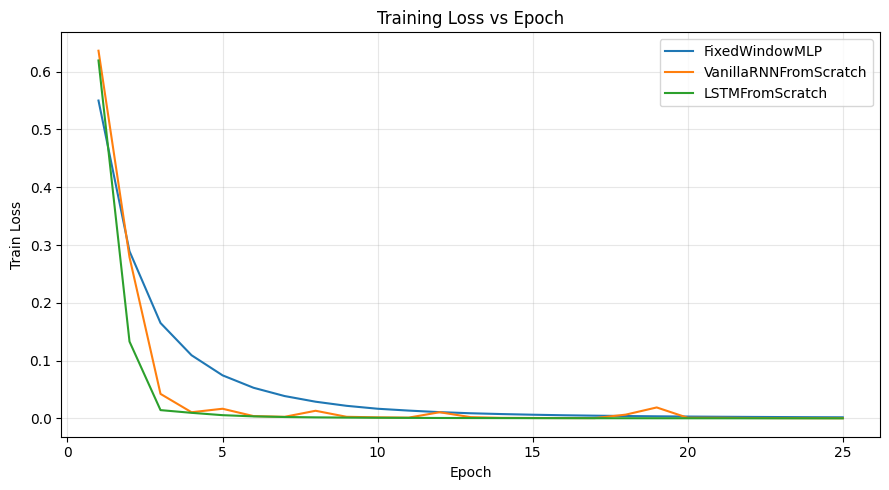

In [19]:
import matplotlib.pyplot as plt

epochs_fixed = range(1, len(fixed_window_history["train_loss"]) + 1)
epochs_rnn = range(1, len(vanilla_rnn_history["train_loss"]) + 1)
epochs_lstm = range(1, len(lstm_history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    epochs_fixed,
    fixed_window_history["train_loss"],
    label="FixedWindowMLP"
)
plt.plot(
    epochs_rnn,
    vanilla_rnn_history["train_loss"],
    label="VanillaRNNFromScratch"
)
plt.plot(
    epochs_lstm,
    lstm_history["train_loss"],
    label="LSTMFromScratch"
)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

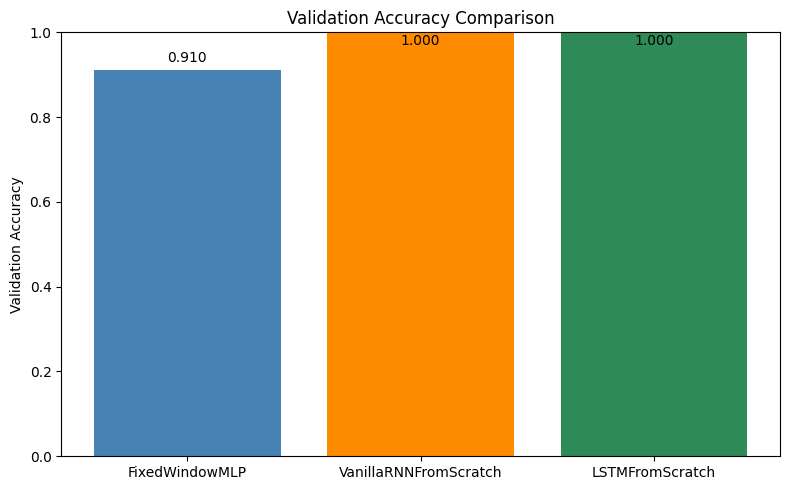

In [20]:
model_names = [
    "FixedWindowMLP",
    "VanillaRNNFromScratch",
    "LSTMFromScratch"
]
validation_accuracies = [
    fixed_window_val_acc,
    vanilla_rnn_val_acc,
    lstm_val_acc
]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    model_names,
    validation_accuracies,
    color=["steelblue", "darkorange", "seagreen"]
)
plt.ylim(0, 1)
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")

for bar, accuracy in zip(bars, validation_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        min(accuracy + 0.02, 0.97),
        f"{accuracy:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [21]:
def inspect_predictions(
    models_dict,
    df,
    token_to_id,
    device,
    num_examples=5
):
    id_to_label = {0: "RED", 1: "BLUE"}
    examples = df[df["split"].eq("val")].head(num_examples)

    for model in models_dict.values():
        model.eval()

    for example_number, (_, row) in enumerate(
        examples.iterrows(),
        start=1
    ):
        tokens = str(row["sequence"]).split()
        token_ids = [token_to_id[token] for token in tokens]
        sequence_tensor = torch.tensor(
            [token_ids],
            dtype=torch.long,
            device=device
        )

        true_label = int(row["label"])
        true_label_name = id_to_label[true_label]

        print(f"\nExample {example_number}")
        print("Sequence:", row["sequence"])
        print("True label_name:", true_label_name)
        print("Distractor count:", row["distractor_count"])

        with torch.no_grad():
            for model_name, model in models_dict.items():
                logits = model(sequence_tensor)
                predicted_id = logits.argmax(dim=1).item()
                predicted_label = id_to_label[predicted_id]
                is_correct = predicted_id == true_label

                print(
                    f"{model_name} prediction: {predicted_label} | "
                    f"Correct: {is_correct}"
                )


models_dict = {
    "FixedWindowMLP": fixed_window_model,
    "VanillaRNNFromScratch": vanilla_rnn_model,
    "LSTMFromScratch": lstm_model
}

inspect_predictions(
    models_dict,
    df,
    token_to_id,
    device,
    num_examples=5
)


Example 1
Sequence: START music machine ocean notebook basketball library planet pizza pencil clock train apple flower silver apple river island book shirt window phone cloud lamp dog shirt cloud dog school kitchen house road desk pencil house orange dog mirror train cloud window bridge flower garden house apple coffee apple cloud road kitchen ocean window violin shirt school violin chair basketball desk mountain school paper basketball pizza kitchen violin library lamp paper island train island mountain cloud island music RED garden BLUE BLUE violin pencil BLUE planet planet music BLUE dog pizza BLUE apple paper BLUE BLUE island basketball camera forest desk book desk clock music house silver lamp BLUE desk notebook bridge BLUE BLUE BLUE BLUE bridge BLUE BLUE forest camera button mirror camera ocean BLUE river machine tree paper ocean garden BLUE BLUE planet lamp BLUE forest BLUE window kitchen stone river car music BLUE river BLUE BLUE BLUE chair tree music apple BLUE music BLUE ora

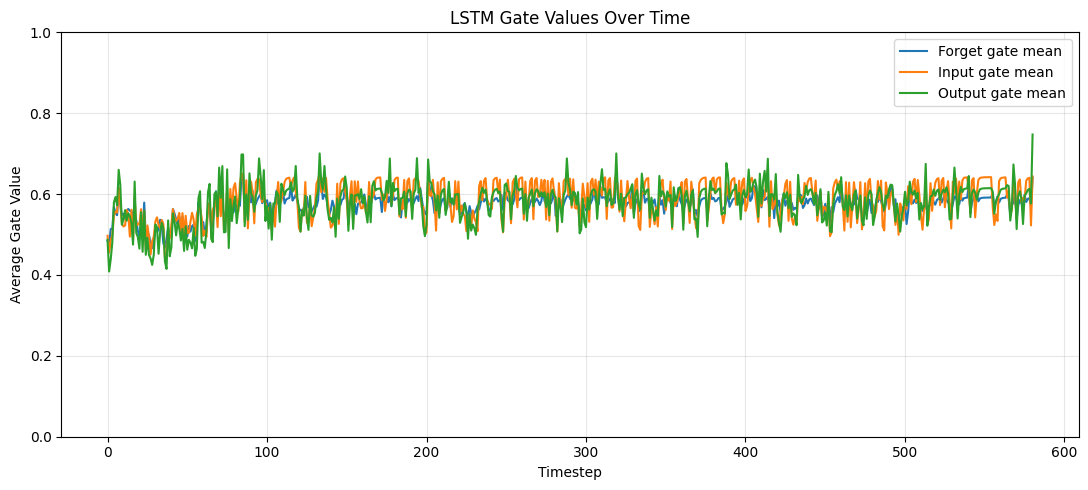

In [22]:
validation_example = df[df["split"].eq("val")].iloc[0]
example_tokens = str(validation_example["sequence"]).split()
example_ids = [token_to_id[token] for token in example_tokens]

example_tensor = torch.tensor(
    [example_ids],
    dtype=torch.long,
    device=device
)

lstm_model.eval()
with torch.no_grad():
    _, gate_values = lstm_model(
        example_tensor,
        return_gates=True
    )

forget_gate_mean = (
    gate_values["forget_gates"]
    .mean(dim=2)
    .squeeze(0)
    .cpu()
    .numpy()
)
input_gate_mean = (
    gate_values["input_gates"]
    .mean(dim=2)
    .squeeze(0)
    .cpu()
    .numpy()
)
output_gate_mean = (
    gate_values["output_gates"]
    .mean(dim=2)
    .squeeze(0)
    .cpu()
    .numpy()
)

timesteps = range(forget_gate_mean.shape[0])

plt.figure(figsize=(11, 5))
plt.plot(timesteps, forget_gate_mean, label="Forget gate mean")
plt.plot(timesteps, input_gate_mean, label="Input gate mean")
plt.plot(timesteps, output_gate_mean, label="Output gate mean")
plt.xlabel("Timestep")
plt.ylabel("Average Gate Value")
plt.title("LSTM Gate Values Over Time")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
print(
    "Dataset tests whether a model can remember the first "
    "RED/BLUE token after START."
)
print("FixedWindowMLP has no real sequence memory.")
print("VanillaRNN has hidden-state memory.")
print("LSTM has gated cell-state memory.")
print("Later RED/BLUE tokens are distractors.")
print("This is why the task demonstrates the purpose of LSTMs.")

Dataset tests whether a model can remember the first RED/BLUE token after START.
FixedWindowMLP has no real sequence memory.
VanillaRNN has hidden-state memory.
LSTM has gated cell-state memory.
Later RED/BLUE tokens are distractors.
This is why the task demonstrates the purpose of LSTMs.


In [24]:
print("CSV path:", csv_path)

print("Min sequence length:", df["sequence_length"].min())
print("Max sequence length:", df["sequence_length"].max())
print("Average sequence length:", df["sequence_length"].mean())

print("\nDifficulty counts:")
print(df["difficulty"].value_counts())

print("\nTrain/val split:")
print(df["split"].value_counts())


df["actual_token_count"] = df["sequence"].astype(str).str.split().str.len()

print("Min actual token count:", df["actual_token_count"].min())
print("Max actual token count:", df["actual_token_count"].max())

print(df[["sequence_length", "actual_token_count", "difficulty"]].head())


print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)


CSV path: /kaggle/input/datasets/punicbyte/500-very-long/synthetic_memory_500_very_long(1).csv
Min sequence length: 150
Max sequence length: 598
Average sequence length: 371.212

Difficulty counts:
difficulty
long      210
medium    194
short      96
Name: count, dtype: int64

Train/val split:
split
train    400
val      100
Name: count, dtype: int64
Min actual token count: 150
Max actual token count: 598
   sequence_length  actual_token_count difficulty
0              207                 207      short
1              492                 492       long
2              493                 493       long
3              374                 374     medium
4              481                 481       long
X_train shape: torch.Size([400, 598])
X_val shape: torch.Size([100, 598])
